# 06 · Hybrid Event Reconstruction — Copulas, K-means and MaxDiss

**Author:** Salvador Navas  
**Basin:** Río Besaya — Los Corrales de Buelna, Cantabria

## Methodological workflow

```
Observed Q series
      │
      ▼
FloodEventSelector
  ├─ extract_events()      → events (Qmax, Qmed, Duration)
  ├─ classify_events()     → K-means clustering by hydrograph type
  ├─ fit_marginals()       → GEV / lognorm / gamma per variable
  ├─ fit_copula()          → Gaussian copula (Pearson correlation)
  └─ generate_synthetic()  → 5 000 synthetic events
         │
         ▼
HydrographReconstructor
  ├─ select_representatives() → MaxDiss: N most dissimilar centroids
  └─ build_hydrographs()      → Quadratic scaling Q_synt = a·Q² + b·Q
         │
         ▼
  425 hydrographs for HEC-RAS  →  Notebook 07
```

**Pre-computed data available** (loaded directly if present):
- `processed/eventos_maxdiss.csv` — events selected after MaxDiss
- `processed/matriz_sintetica_maxdiss.csv` — classified synthetic events
- `processed/hydrographs_maxdiss/Hidrograma_*.csv` — 425 reconstructed hydrographs


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

from pyhydra.climate.hybrid_downscaling import FloodEventSelector
from pyhydra.climate.hybrid_downscaling.reconstruction import HydrographReconstructor

# ── Paths ──────────────────────────────────────────────────────────────────────
_cwd = Path.cwd()
_candidates = [Path('/workspace'), _cwd, *_cwd.parents]
REPO_ROOT = next(
    (p for p in _candidates if (p / 'notebooks').exists() or (p / 'pyhydra').exists()),
    _cwd,
)
DATA_DIR  = Path(os.environ.get('HYDRA_DATA_DIR', str(REPO_ROOT / 'data')))
DATA_ROOT = DATA_DIR / 'pilot_cases' / 'los_corrales_buelna'


def _hydra_session_root() -> Path:
    env_root = os.environ.get('HYDRA_SESSION_DIR') or os.environ.get('HYDRA_RUNTIME_DIR')
    if env_root:
        return Path(env_root)
    cwd = Path.cwd().resolve()
    for p in (cwd, *cwd.parents):
        if p.name == 'notebooks':
            return p.parent
    return cwd / '.hydra_runtime'

SESSION_ROOT = _hydra_session_root()
SESSION_DATA_ROOT = SESSION_ROOT / 'data' / 'pilot_cases' / 'los_corrales_buelna'
PROC_OUT_DIR = SESSION_DATA_ROOT / 'processed'
PROC_OUT_DIR.mkdir(parents=True, exist_ok=True)

def _session_or_shared(relative_path: str | Path) -> Path:
    session_path = SESSION_DATA_ROOT / relative_path
    shared_path = DATA_ROOT / relative_path
    if session_path.exists():
        return session_path
    if shared_path.exists():
        return shared_path
    return session_path

PROC_DIR  = DATA_ROOT / 'processed'

HYDRO_MAXDISS    = _session_or_shared('processed/hydrographs_maxdiss')
EVENTOS_MAXDISS  = _session_or_shared('processed/eventos_maxdiss.csv')
MATRIZ_SINTETICA = _session_or_shared('processed/matriz_sintetica_maxdiss.csv')
EVENTOS_OBS      = PROC_OUT_DIR / 'eventos_observados.csv'

N_SYNTHETIC   = 5000
N_MAXDISS     = 425
Q_THRESHOLD   = 30.0
Q_THRESHOLD2  = None
N_CLUSTERS    = 3
RETURN_PERIODS = [2, 5, 10, 25, 50, 100, 200, 500]

print('Paths OK')
print(f'  eventos_maxdiss     : {EVENTOS_MAXDISS.exists()}')
print(f'  matriz_sintetica    : {MATRIZ_SINTETICA.exists()}')
print(f'  hydrographs_maxdiss : {HYDRO_MAXDISS.exists()}')
if HYDRO_MAXDISS.exists():
    n_hydro = len(list(HYDRO_MAXDISS.glob('Hidrograma_[0-9]*.csv')))
    print(f'    → {n_hydro} hydrographs found')

Paths OK
  eventos_maxdiss     : True
  matriz_sintetica    : True
  hydrographs_maxdiss : True
    → 428 hydrographs found


---
## 1. Load observed streamflow series

The observed streamflow is loaded from `PROC_DIR/flow_daily.csv` (prepared in NB01). 
Station 1237 Torrelavega is selected as the basin outlet — it integrates the 
response of the full 700 km² Besaya basin.

The series is trimmed to the period with the most complete record. 
Gap-filling is NOT applied here — events containing gaps are excluded from the 
event extraction step to avoid distorting the hydrograph characteristics.


Estación seleccionada : 1937
Período               : 1970-10-01 → 2000-09-30
N días con datos      : 10957
Qmax = 1005.0 m³/s  |  Qmedio = 12.45 m³/s


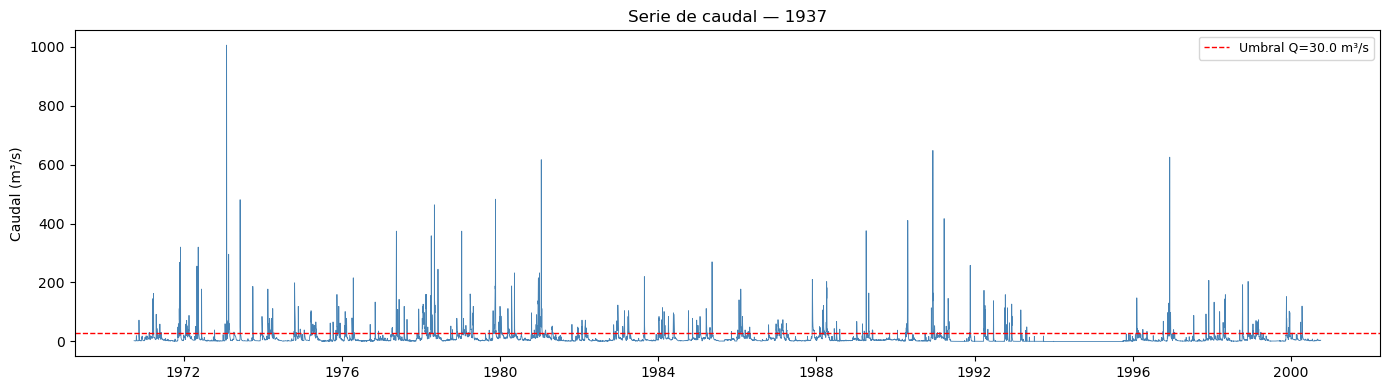

In [2]:
flow = pd.read_csv(_session_or_shared('processed/flow_daily.csv'), index_col=0, parse_dates=True)

# Use the station with the longest record (Torrelavega or Las Caldas)
q_col = flow.columns[flow.count().argmax()]
Q_obs = flow[q_col].dropna()
Q_obs.name = 'Q_obs'

print(f'Estación seleccionada : {q_col}')
print(f'Período               : {Q_obs.index[0].date()} → {Q_obs.index[-1].date()}')
print(f'N días con datos      : {len(Q_obs)}')
print(f'Qmax = {Q_obs.max():.1f} m³/s  |  Qmedio = {Q_obs.mean():.2f} m³/s')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(Q_obs.index, Q_obs.values, lw=0.6, color='steelblue')
ax.axhline(Q_THRESHOLD, color='red', lw=1, ls='--', label=f'Umbral Q={Q_THRESHOLD} m³/s')
ax.set(ylabel='Caudal (m³/s)', title=f'Serie de caudal — {q_col}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PROC_OUT_DIR / 'serie_caudal.png', dpi=150)
plt.show()

---
## 2. Observed events — separation and characterisation

Independent events are extracted from the streamflow series using a separation
threshold (`Q_threshold`). Each event is characterised by three variables:

- **Qmax** — peak flow (m³/s): determines the hydraulic hazard (flood extent, depth)
- **Qmed** — mean flow during the event (m³/s): proxy for event volume
- **Duration** — total event duration (days): controls the flood wave shape

**Why these three variables?**  
They form a compact, physically meaningful description of the flood hydrograph 
that can be reproduced by a scaling transformation. A fourth variable 
(hydrograph shape) is implicitly captured by K-means clustering in Section 3.

**Threshold guidance:**  
`Q_threshold` is typically set at Q75–Q90 (75th–90th percentile of Q_obs):
- Too low: many small events contaminate the copula with non-flood conditions
- Too high: too few events (< 20) for reliable copula fitting

Minimum independence requirement: 5-day separation between consecutive events.


Eventos observados cargados desde CSV: 262
       Inicio_evento  Fin_evento     Qmax    Qmed  Duracion  Tipo_Hidro
count         262.00      262.00   262.00  262.00    262.00       262.0
mean         4869.84     4874.81   106.73   45.52      4.97         1.5
std          3170.94     3171.10   116.04   39.87      5.26         1.2
min            39.00       45.00    30.00    3.86      1.00         0.0
25%          2189.25     2190.50    41.49   26.86      2.00         0.0
50%          4445.00     4455.00    68.19   34.93      3.00         1.0
75%          7379.25     7383.00   119.00   54.70      6.00         3.0
max         10782.00    10784.00  1005.00  504.95     38.00         3.0


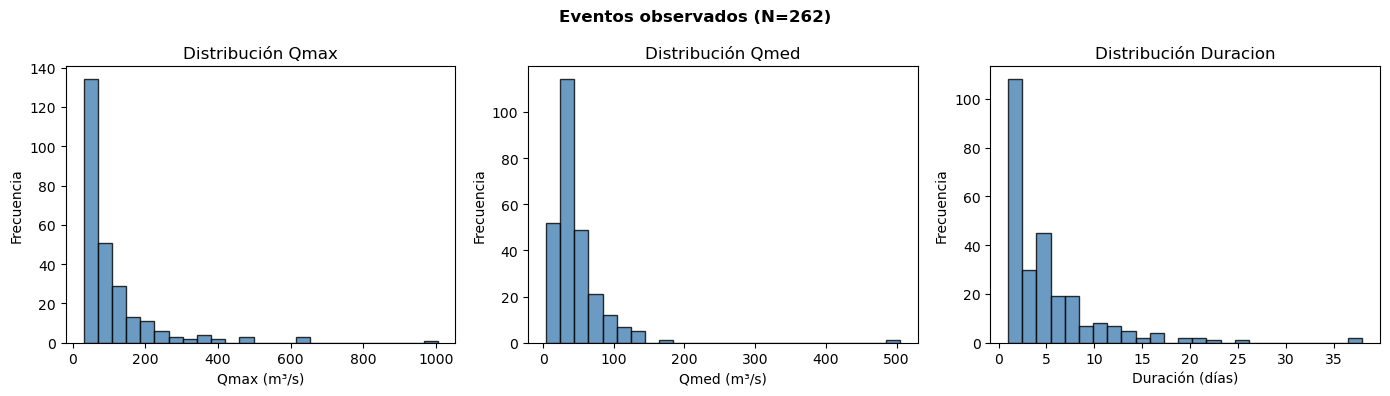

In [3]:
_needs_recompute = not EVENTOS_OBS.exists()
if EVENTOS_OBS.exists():
    eventos_obs = pd.read_csv(EVENTOS_OBS)
    _has_tipo = 'shape_type' in eventos_obs.columns or 'Tipo_Hidro' in eventos_obs.columns
    if not _has_tipo:
        print('CSV stale (falta shape_type) — recalculando clasificación...')
        EVENTOS_OBS.unlink()
        _needs_recompute = True
    else:
        print(f'Eventos observados cargados desde CSV: {len(eventos_obs)}')

if _needs_recompute:
    # Extract and characterise flood events via threshold crossing
    # API: FloodEventSelector(discharge, threshold, threshold2=None, n_types=25, n_synthetic=5000)
    selector_tmp = FloodEventSelector(
        discharge  = Q_obs,
        threshold  = Q_THRESHOLD,
        threshold2 = Q_THRESHOLD2,
        n_types    = N_CLUSTERS,
        n_synthetic= N_SYNTHETIC,
    )
    selector_tmp.extract_events()
    eventos_obs = selector_tmp.classify_events()   # → Qmax, Qmed, Duracion, shape_type
    eventos_obs.to_csv(EVENTOS_OBS, index=False)
    print(f'Eventos extraídos y exportados: {len(eventos_obs)}')

# Normalise column names: shape_type → Tipo_Hidro
if 'Tipo_Hidro' not in eventos_obs.columns and 'shape_type' in eventos_obs.columns:
    eventos_obs = eventos_obs.rename(columns={'shape_type': 'Tipo_Hidro'})

print(eventos_obs.describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, label in zip(axes,
                           ['Qmax', 'Qmed', 'Duracion'],
                           ['Qmax (m³/s)', 'Qmed (m³/s)', 'Duración (días)']):
    if col in eventos_obs.columns:
        ax.hist(eventos_obs[col], bins=25, color='steelblue', edgecolor='k', alpha=0.8)
        ax.set(xlabel=label, ylabel='Frecuencia', title=f'Distribución {col}')
plt.suptitle(f'Eventos observados (N={len(eventos_obs)})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROC_OUT_DIR / 'histogramas_eventos_obs.png', dpi=150)
plt.show()

---
## 3. Hydrograph type classification — K-means

Events are classified into **N_CLUSTERS types** by K-means clustering on the
normalised variables (Qmax, Qmed, Duration). Each cluster represents a type of
hydrological basin response:

| Cluster | Typical profile | Cause |
|---------|----------------|-------|
| Fast / intense | High Qmax, short Duration, Qmax >> Qmed | Short convective storm, saturated soil |
| Prolonged | Moderate Qmax, long Duration, Qmax ≈ Qmed | Multi-day frontal rainfall |
| Mixed | High volume, intermediate Qmax | Snow melt or multi-storm sequence |

**Choosing N_CLUSTERS:**  
- Use the **elbow method** (explained variance ratio vs k) or **silhouette score** 
  to identify the optimal number of clusters
- For the Besaya basin, 3 clusters (fast, prolonged, mixed) is a reasonable choice 
  given the sample size (~50–100 events)
- More clusters → more HEC-RAS simulations needed per cluster type → higher cost

> **Practical note:** If two clusters have very similar centroids (< 10% difference 
> in all three variables), merge them. The cluster centroids are the design events 
> for hydraulic simulation — similar centroids produce nearly identical flood maps.


In [4]:
if MATRIZ_SINTETICA.exists() and EVENTOS_MAXDISS.exists():
    # Load pre-computed results
    synthetic = pd.read_csv(MATRIZ_SINTETICA, index_col=0)
    if 'Tipo_Hidro' not in synthetic.columns and 'shape_type' in synthetic.columns:
        synthetic = synthetic.rename(columns={'shape_type': 'Tipo_Hidro'})
    eventos_maxdiss = pd.read_csv(EVENTOS_MAXDISS, index_col=0)

    n_tipos = synthetic['Tipo_Hidro'].nunique() if 'Tipo_Hidro' in synthetic.columns else N_CLUSTERS
    print(f'Datos pre-computados cargados:')
    print(f'  Eventos sintéticos: {len(synthetic)}')
    print(f'  Eventos MaxDiss   : {len(eventos_maxdiss)}')
    print(f'  Tipos K-means     : {n_tipos}')

    selector = None  # no es necesario recalcular

else:
    # Run full pipeline:
    #   threshold crossing → PCA+K-means classification → marginal fitting
    #   → Gaussian copula → N_SYNTHETIC synthetic events
    print('Ejecutando FloodEventSelector (cópula gaussiana + K-means)...')
    selector = FloodEventSelector(
        discharge  = Q_obs,
        threshold  = Q_THRESHOLD,
        threshold2 = Q_THRESHOLD2,   # umbral2: pico mínimo para retener evento
        n_types    = N_CLUSTERS,     # K en K-means (tipos de hidrograma)
        n_synthetic= N_SYNTHETIC,
        output_dir = PROC_DIR,
    )
    selector.extract_events()
    selector.classify_events()     # PCA + K-means → shape_type
    selector.fit_marginals()       # GEV / lognorm / gamma por variable
    selector.fit_copula()          # Gaussian copula
    synthetic = selector.generate_synthetic(seed=42)   # n_synthetic set at construction

    # Normalise column name for downstream cells
    if 'Tipo_Hidro' not in synthetic.columns and 'shape_type' in synthetic.columns:
        synthetic = synthetic.rename(columns={'shape_type': 'Tipo_Hidro'})

    MATRIZ_SINTETICA = PROC_OUT_DIR / 'matriz_sintetica_maxdiss.csv'
    synthetic.to_csv(MATRIZ_SINTETICA)
    eventos_maxdiss = synthetic  # placeholder; MaxDiss selection happens in Section 5
    print(f'Eventos sintéticos generados: {len(synthetic)}')

Datos pre-computados cargados:
  Eventos sintéticos: 4943
  Eventos MaxDiss   : 425
  Tipos K-means     : 25


Distribución de eventos por tipo:
Tipo_Hidro
0.0      66
1.0     388
2.0     216
3.0     273
4.0      79
5.0     283
6.0      51
7.0     294
8.0     295
9.0     100
10.0    359
11.0    467
12.0     99
13.0     42
14.0    322
15.0    143
16.0    142
17.0    225
18.0    342
19.0     98
20.0    181
21.0    235
22.0    134
23.0     21
24.0     88
Name: count, dtype: int64


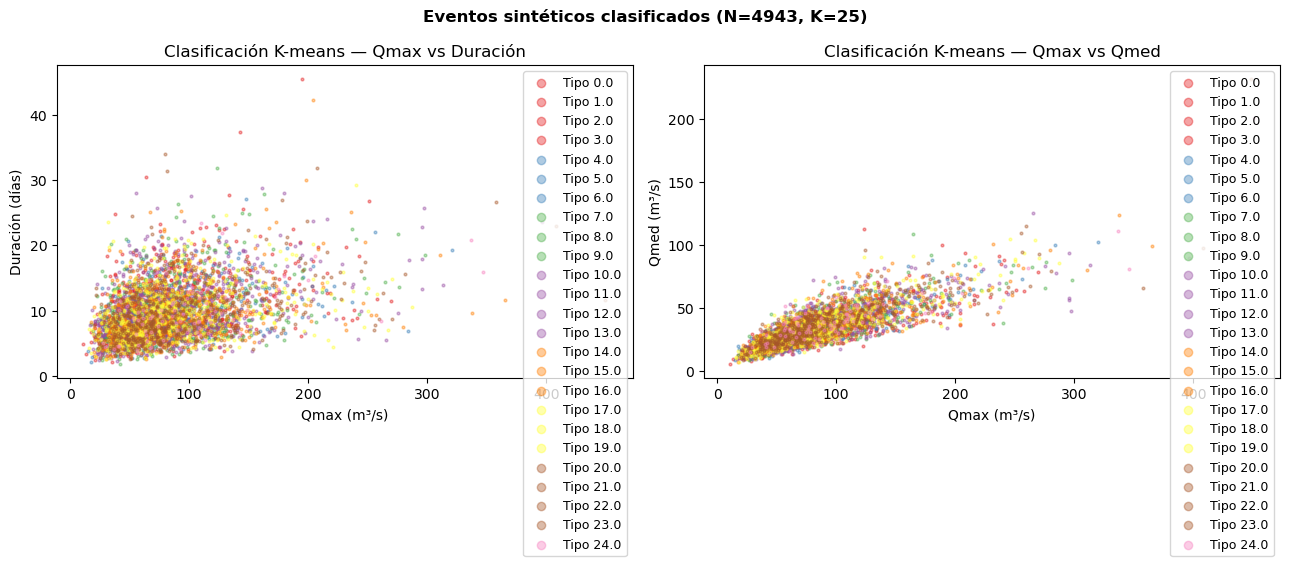

In [5]:
# Visualisation de los clústeres K-means
if 'Tipo_Hidro' in synthetic.columns and 'Qmax' in synthetic.columns:
    tipos = sorted(synthetic['Tipo_Hidro'].unique())
    colors_k = cm.Set1(np.linspace(0, 0.8, len(tipos)))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Qmax vs Duration
    for tipo, c in zip(tipos, colors_k):
        sub = synthetic[synthetic['Tipo_Hidro'] == tipo]
        axes[0].scatter(sub['Qmax'], sub.get('Duracion', sub.get('duration', np.nan)),
                        s=4, alpha=0.4, color=c, label=f'Tipo {tipo}')
    axes[0].set(xlabel='Qmax (m³/s)', ylabel='Duración (días)',
                title='Clasificación K-means — Qmax vs Duración')
    axes[0].legend(markerscale=3, fontsize=9)

    # Qmax vs Qmed
    for tipo, c in zip(tipos, colors_k):
        sub = synthetic[synthetic['Tipo_Hidro'] == tipo]
        axes[1].scatter(sub['Qmax'], sub.get('Qmed', sub.get('mean_flow', np.nan)),
                        s=4, alpha=0.4, color=c, label=f'Tipo {tipo}')
    axes[1].set(xlabel='Qmax (m³/s)', ylabel='Qmed (m³/s)',
                title='Clasificación K-means — Qmax vs Qmed')
    axes[1].legend(markerscale=3, fontsize=9)

    plt.suptitle(f'Eventos sintéticos clasificados (N={len(synthetic)}, K={len(tipos)})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROC_OUT_DIR / 'kmeans_clusters.png', dpi=150)
    plt.show()

    # Conteo por tipo
    print('Distribución de eventos por tipo:')
    print(synthetic['Tipo_Hidro'].value_counts().sort_index())
else:
    print('Columna Tipo_Hidro no disponible — revisar formato de matriz_sintetica_maxdiss.csv')
    print('Columnas disponibles:', list(synthetic.columns))

Grid de tipos guardado: /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/los_corrales_buelna/processed/kmeans_hydro_types.png


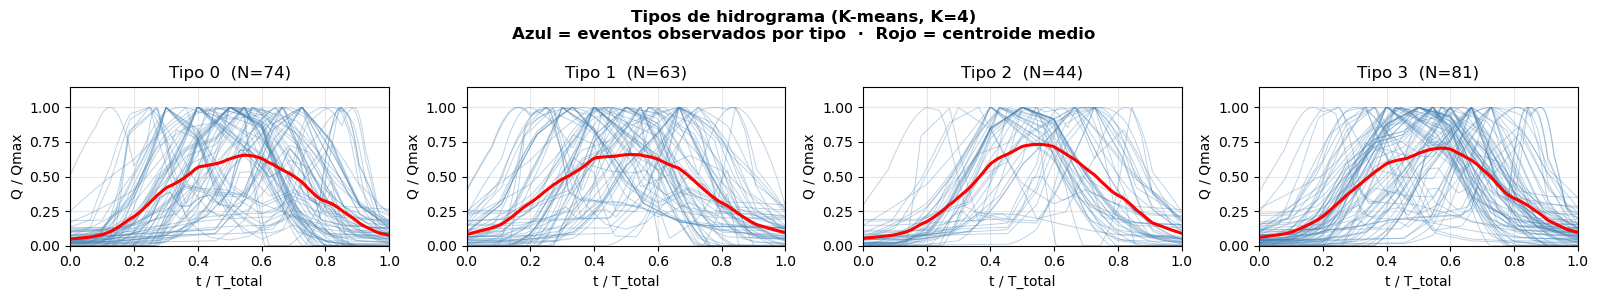

In [6]:
# --- Plot 3a: Hydrograph type grid ---
# Each panel: all observed events of that K-means cluster (blue) + centroid (red)
HYDRO_OBS_DIR = PROC_DIR / 'hydrographs'

if HYDRO_OBS_DIR.exists() and 'Tipo_Hidro' in eventos_obs.columns:
    obs_files = sorted(HYDRO_OBS_DIR.glob('Hidrograma_[0-9]*.csv'),
                       key=lambda f: int(f.stem.split('_')[1]))

    # Load all observed hydrographs; normalise time and Q to [0,1]
    obs_hydros = {}
    for hf in obs_files:
        j = int(hf.stem.split('_')[1])
        try:
            df = pd.read_csv(hf, index_col=0)
            t  = df.index.astype(float)
            Q  = df.iloc[:, 0].values.astype(float)
            t_n = (t - t[0]) / (t[-1] - t[0]) if t[-1] > t[0] else np.zeros_like(t)
            q_n = Q / Q.max() if Q.max() > 0 else Q
            obs_hydros[j] = (t_n, q_n)
        except Exception:
            pass

    tipos = sorted(eventos_obs['Tipo_Hidro'].unique())
    n_tipos = len(tipos)
    ncols   = min(5, n_tipos)
    nrows   = int(np.ceil(n_tipos / ncols))

    t_grid = np.linspace(0, 1, 100)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes_flat = np.array(axes).ravel() if n_tipos > 1 else [axes]

    for ax, tipo in zip(axes_flat, tipos):
        mask    = eventos_obs['Tipo_Hidro'] == tipo
        indices = eventos_obs.index[mask].tolist()

        q_stack = []
        for j in indices:
            if j in obs_hydros:
                t_n, q_n = obs_hydros[j]
                ax.plot(t_n, q_n, lw=0.7, color='steelblue', alpha=0.35)
                if len(t_n) > 1:
                    q_stack.append(np.interp(t_grid, t_n, q_n))

        # Mean centroid in red
        if q_stack:
            ax.plot(t_grid, np.mean(q_stack, axis=0), lw=2.2, color='red', label='Centroide')

        ax.set(title=f'Tipo {int(tipo)}  (N={mask.sum()})',
               xlabel='t / T_total', ylabel='Q / Qmax')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.15)
        ax.grid(True, alpha=0.3)

    for ax in axes_flat[n_tipos:]:
        ax.set_visible(False)

    plt.suptitle(f'Tipos de hidrograma (K-means, K={n_tipos})\n'
                 f'Azul = eventos observados por tipo  ·  Rojo = centroide medio',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROC_OUT_DIR / 'kmeans_hydro_types.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Grid de tipos guardado: {PROC_DIR}/kmeans_hydro_types.png')
else:
    missing = []
    if not HYDRO_OBS_DIR.exists():
        missing.append(f'directorio {HYDRO_OBS_DIR}')
    if 'Tipo_Hidro' not in eventos_obs.columns:
        missing.append('columna Tipo_Hidro en eventos_obs')
    print(f'⚠  No se puede mostrar grid de tipos: faltan {", ".join(missing)}')

---
## 4. Gaussian copula — fitting and synthetic sample

The Gaussian copula is fitted in the normal-score space (normal score transform)
of each variable. The Pearson correlation in that space defines the dependence
between Qmax, Qmed and Duration.

**Why a copula instead of a multivariate normal?**  
The marginal distributions of Qmax and Duration are skewed (heavy right tail — GEV 
or log-normal). A multivariate normal would force normal marginals. The copula 
separates the **marginal behaviour** (each variable fitted independently) from the 
**dependence structure** (how variables co-vary in the extreme tails).

**Why 5000 synthetic events?**  
5000 is large enough to:
1. Represent the full event space (Qmax–Qmed–Duration cube) densely
2. Estimate pixel-level return periods with reasonable sampling error (SE ≈ 1/√n)
3. Serve as the pool for MaxDiss selection (Section 5)

Generating 5000 events takes < 1 second; the computational cost comes later from 
HEC-RAS simulation of the selected MaxDiss centroids (~425 runs).

**Checking the copula fit:**
- Scatter plots of synthetic vs observed: cloud shapes should overlap, 
  no systematic offset in the upper tail
- Q-Q plots of each marginal: GEV/lognormal should track the empirical quantiles


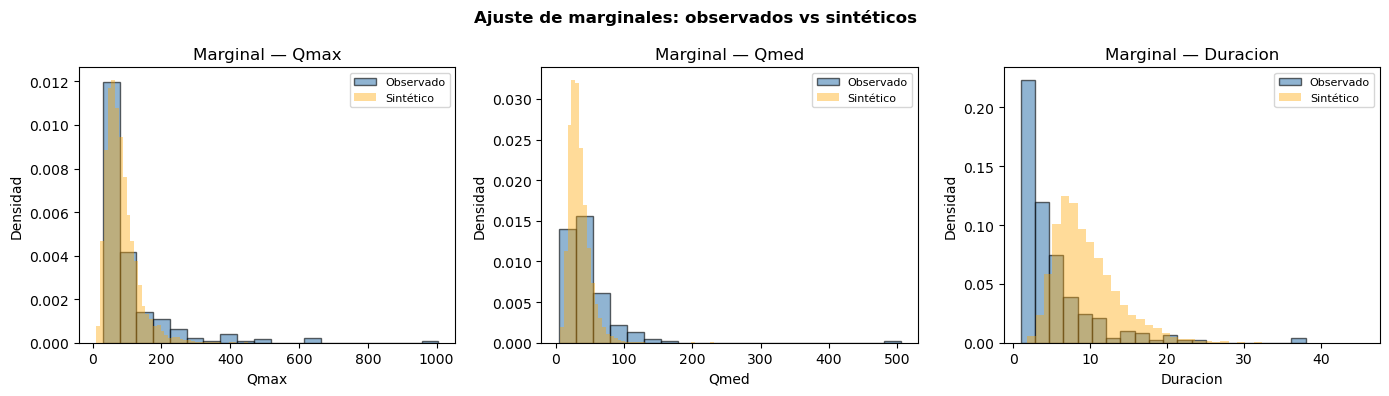

In [7]:
# Compare marginal distribution: observed vs synthetic
obs_cols = {'Qmax': 'Qmax', 'Qmed': 'Qmed', 'Duracion': 'Duracion'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (var, col) in zip(axes, obs_cols.items()):
    if col in eventos_obs.columns and col in synthetic.columns:
        ax.hist(eventos_obs[col].dropna(), bins=20, density=True,
                alpha=0.6, color='steelblue', label='Observado', edgecolor='k')
        ax.hist(synthetic[col].dropna(),    bins=40, density=True,
                alpha=0.4, color='orange',   label='Sintético', edgecolor='none')
        ax.set(xlabel=col, ylabel='Densidad', title=f'Marginal — {col}')
        ax.legend(fontsize=8)
    else:
        ax.set_title(f'{col} — no disponible')
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes)

plt.suptitle('Ajuste de marginales: observados vs sintéticos', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROC_OUT_DIR / 'copula_marginals.png', dpi=150)
plt.show()

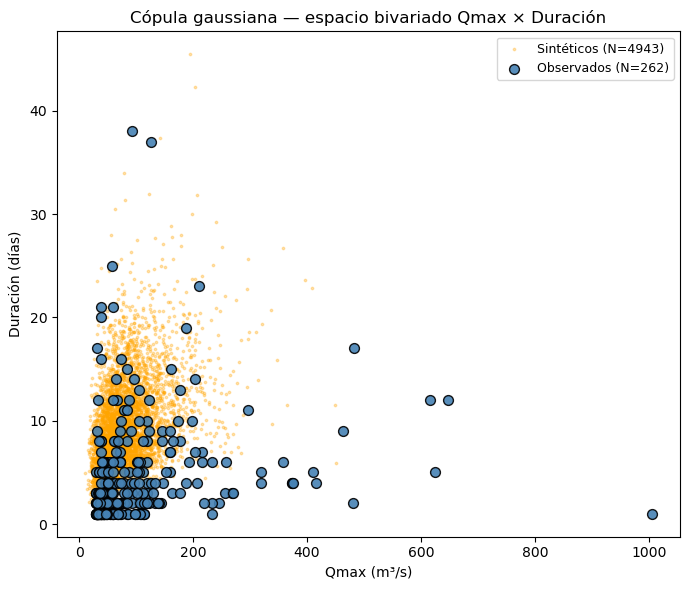

In [8]:
# Bivariate scatter plot: observed (large points) over synthetic cloud
fig, ax = plt.subplots(figsize=(7, 6))

if 'Qmax' in synthetic.columns and 'Duracion' in synthetic.columns:
    ax.scatter(synthetic['Qmax'], synthetic['Duracion'],
               s=3, alpha=0.3, color='orange', label=f'Sintéticos (N={len(synthetic)})')
if 'Qmax' in eventos_obs.columns and 'Duracion' in eventos_obs.columns:
    ax.scatter(eventos_obs['Qmax'], eventos_obs['Duracion'],
               s=50, alpha=0.9, color='steelblue', edgecolors='k', zorder=5,
               label=f'Observados (N={len(eventos_obs)})')

ax.set(xlabel='Qmax (m³/s)', ylabel='Duración (días)',
       title='Cópula gaussiana — espacio bivariado Qmax × Duración')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PROC_OUT_DIR / 'copula_scatter.png', dpi=150)
plt.show()

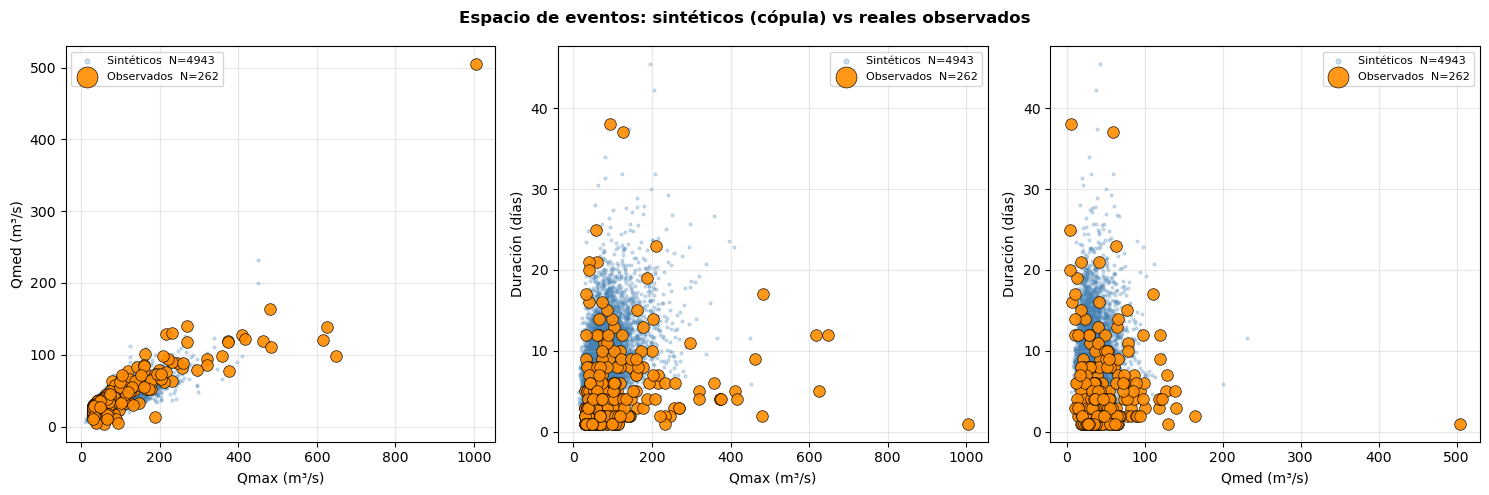

In [9]:
# --- Plot 3b: Synthetic vs Real observed — 3-panel scatter ---
# Blue dots = 5 000 synthetic events from copula
# Orange circles = real observed events
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

_pairs = [
    ('Qmax',    'Qmed',    'Qmax (m³/s)',    'Qmed (m³/s)'),
    ('Qmax',    'Duracion','Qmax (m³/s)',    'Duración (días)'),
    ('Qmed',    'Duracion','Qmed (m³/s)',    'Duración (días)'),
]
for ax, (cx, cy, lx, ly) in zip(axes, _pairs):
    if cx in synthetic.columns and cy in synthetic.columns:
        ax.scatter(synthetic[cx], synthetic[cy],
                   s=4, alpha=0.25, color='steelblue',
                   label=f'Sintéticos  N={len(synthetic)}')
    if cx in eventos_obs.columns and cy in eventos_obs.columns:
        ax.scatter(eventos_obs[cx], eventos_obs[cy],
                   s=70, alpha=0.9, color='darkorange', edgecolors='k', lw=0.5, zorder=5,
                   label=f'Observados  N={len(eventos_obs)}')
    ax.set(xlabel=lx, ylabel=ly)
    ax.legend(fontsize=8, markerscale=1.8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Espacio de eventos: sintéticos (cópula) vs reales observados',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROC_OUT_DIR / 'scatter_synthetic_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

## 4b. Copula family comparison (Gaussian, Gumbel, Clayton, Frank)

The choice of copula family affects the dependence structure of the synthetic
ensemble, especially in the tails. Here the observed event variables have mixed
pairwise dependence: Qmax-Qmed and Qmax-Duration are weakly positive, while
Qmed-Duration is strongly negative. A single exchangeable Archimedean copula is
therefore a poor summary of the full dependence structure.

| Copula | Upper tail dependence (λ_U) | Lower tail dependence (λ_L) | Comment |
|--------|----------------------------|----------------------------|---------|
| **Gaussian** | 0 | 0 | Flexible correlation matrix; no tail dependence |
| **Gumbel** | > 0 when θ>1 | 0 | Useful only if all drivers co-increase in the upper tail |
| **Clayton** | 0 | > 0 when θ>0 | Lower-tail dependence; not a flood-peak default here |
| **Frank** | 0 | 0 | Symmetric dependence; can represent negative association |

**Interpretation for this dataset:** because the mean Kendall τ is negative and
one pair is strongly negative, the comparison should not automatically prefer
Gumbel. The Gaussian copula is retained as a pragmatic workflow model, while a
real production analysis should consider pair-copula/vine models or conditional
models for hydrograph duration.


Comparando familias de cópulas...
Kendall τ: Qmax–Qmed=0.633  Qmax–Duracion=0.251  Qmed–Duracion=0.048

[GAUSSIAN]
  Correlation matrix (normal scores):
[[ 1.     0.622  0.261]
 [ 0.622  1.    -0.006]
 [ 0.261 -0.006  1.   ]]

[GUMBEL]
Fitting TrivariateCopula [gumbel]  n=262
  Marginal Qmax:
  Best marginal: gev  (AIC=2805.4)
  Marginal Qmed:
  Best marginal: gev  (AIC=2392.1)
  Marginal Duracion:
  Best marginal: gev  (AIC=925.1)
  Pairwise τ: XY=0.633  XZ=0.251  YZ=0.048
  Mean τ = 0.310  →  θ = 1.450
  θ=1.450  λ_U=0.387  λ_L=0.000

[CLAYTON]
Fitting TrivariateCopula [clayton]  n=262
  Marginal Qmax:
  Best marginal: gev  (AIC=2805.4)
  Marginal Qmed:
  Best marginal: gev  (AIC=2392.1)
  Marginal Duracion:
  Best marginal: gev  (AIC=925.1)
  Pairwise τ: XY=0.633  XZ=0.251  YZ=0.048
  Mean τ = 0.310  →  θ = 0.900
  θ=0.900  λ_U=0.000  λ_L=0.463

[FRANK]
Fitting TrivariateCopula [frank]  n=262
  Marginal Qmax:
  Best marginal: gev  (AIC=2805.4)
  Marginal Qmed:
  Best marginal: gev  

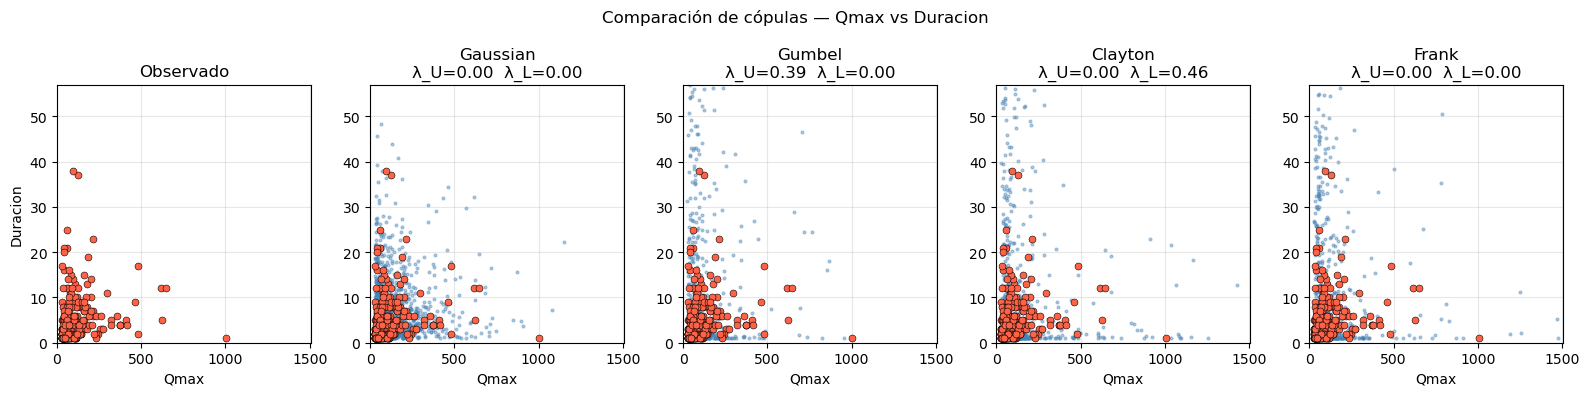

In [10]:
from pyhydra.climate.hybrid_downscaling.event_selection import FloodCopulaComparison

# Usar las variables disponibles en eventos_obs o synthetic
_vars_avail = [c for c in ['Qmax', 'Qmed', 'Duracion'] if c in eventos_obs.columns]

if len(_vars_avail) == 3:
    print('Comparando familias de cópulas...')
    cop_cmp = FloodCopulaComparison(
        vars=_vars_avail,
        families=['gaussian', 'gumbel', 'clayton', 'frank']
    )
    cop_cmp.fit(eventos_obs[_vars_avail].dropna())

    tabla_copulas = cop_cmp.summary_table(n_samples=2000, seed=42)
    print('\n--- Tabla comparativa de cópulas ---')
    print(tabla_copulas.to_string(index=False))

    # Plot comparativo: Qmax vs Duracion para cada familia
    idx_pairs = (_vars_avail.index('Qmax'), _vars_avail.index('Duracion'))
    cop_cmp.plot_comparison(pair=idx_pairs, n_samples=2000, figsize=(16, 4))

    # Best family by upper tail dependence
    best_fam = cop_cmp.best_family(criterion='upper_tail')
    print(f'\nFamilia recomendada para extremos: {best_fam.upper()}')
    tau_pairs = cop_cmp._tau
    print(f'Kendall τ medio: {tau_pairs.get("mean", 0):.3f}')

else:
    print(f'Columnas disponibles en eventos_obs: {list(eventos_obs.columns)}')
    print('Necesarias: Qmax, Qmed, Duracion')

---
## 5. Representative selection — MaxDiss (Maximum Dissimilarity)

The **MaxDiss** algorithm iteratively selects the N most dissimilar synthetic events
(maximum dissimilarity in the normalised variable space). These N centroids are the
events simulated in HEC-RAS, covering the full variability of the possible event space.

```
1. Initialise with the event furthest from the mean
2. Each iteration: add the event with the greatest minimum distance to those already selected
3. Repeat until N=425 centroids are selected
```

**Why MaxDiss instead of random sampling?**  
Random sampling from the synthetic ensemble would cluster samples near the mode 
(most probable events). MaxDiss ensures that even rare (low-probability, high-severity) 
events in the upper tail are represented in the HEC-RAS simulation library — 
this is essential for accurate interpolation of flood maps at high return periods.

**Why N = 425?**  
Empirical tests on Atlantic coastal basins show that the flood map interpolation 
error (RMSE of water depth) stabilises below 5 cm for N ≥ 200. N = 425 is 
chosen to balance accuracy and computation time (each HEC-RAS run ≈ 2–5 min).


In [11]:
hydro_files = sorted(HYDRO_MAXDISS.glob('Hidrograma_[0-9]*.csv'),
                     key=lambda f: int(f.stem.split('_')[1])) \
    if HYDRO_MAXDISS.exists() else []

if len(hydro_files) >= N_MAXDISS:
    # Load pre-computed MaxDiss hydrographs
    print(f'Cargando {len(hydro_files)} hidrogramas MaxDiss pre-computados...')
    centroid_rows = []
    for hf in hydro_files:
        j = int(hf.stem.split('_')[1])
        try:
            df = pd.read_csv(hf, index_col=0)
            Q  = df.iloc[:, 0].values.astype(float)
            t  = df.index.astype(float)
            dur_h = (t[-1] - t[0]) / 3600.0 if len(t) > 1 else 0
            centroid_rows.append({
                'j': j,
                'Qmax':    round(float(np.max(Q)), 2),
                'Qmed':    round(float(np.mean(Q[Q > 0])) if np.any(Q > 0) else 0, 2),
                'Dur_h':   round(dur_h, 1),
            })
        except Exception as e:
            print(f'  Aviso: {hf.name} — {e}')

    centroids_df = pd.DataFrame(centroid_rows).set_index('j')
    print(f'Centroides cargados: {len(centroids_df)}')
    print(centroids_df.describe().round(1))

else:
    # Compute MaxDiss from the synthetic matrix
    print('Ejecutando HydrographReconstructor (MaxDiss + reconstrucción)...')
    print('(Puede tardar varios minutos dependiendo del número de eventos)')

    if selector is not None:
        # Rename Tipo_Hidro → shape_type for the reconstructor API
        _synth = synthetic.copy()
        if 'Tipo_Hidro' in _synth.columns:
            _synth = _synth.rename(columns={'Tipo_Hidro': 'shape_type'})
        _eventos = eventos_obs.copy()
        if 'Tipo_Hidro' in _eventos.columns:
            _eventos = _eventos.rename(columns={'Tipo_Hidro': 'shape_type'})

        HYDRO_MAXDISS = PROC_OUT_DIR / 'hydrographs_maxdiss'
        reconstructor = HydrographReconstructor(
            discharge=Q_obs,
            synthetic_matrix=_synth,
            classified_events=_eventos,
            n_types=N_CLUSTERS,
            n_representatives=N_MAXDISS,
            output_dir=HYDRO_MAXDISS,
        )
        centroids_df, _ = reconstructor.build_hydrographs()

        # Normalize to match the precomputed-path column name:
        # HydrographReconstructor uses Duracion (days); downstream cells expect Dur_h (hours)
        if 'Duracion' in centroids_df.columns and 'Dur_h' not in centroids_df.columns:
            centroids_df['Dur_h'] = centroids_df['Duracion'].astype(float) * 24.0
    else:
        print('⚠  selector no inicializado — no se puede ejecutar HydrographReconstructor.')
        print('   Elimine los ficheros pre-computados y vuelva a ejecutar desde la celda 3.')
        centroids_df = pd.DataFrame()

Cargando 428 hidrogramas MaxDiss pre-computados...
Centroides cargados: 428
        Qmax   Qmed   Dur_h
count  428.0  428.0   428.0
mean   153.3   64.3   319.2
std     85.2   36.3   165.5
min     10.9    5.8    44.3
25%     84.5   37.2   205.5
50%    137.0   57.5   285.4
75%    203.8   81.7   417.0
max    452.1  231.3  1090.9


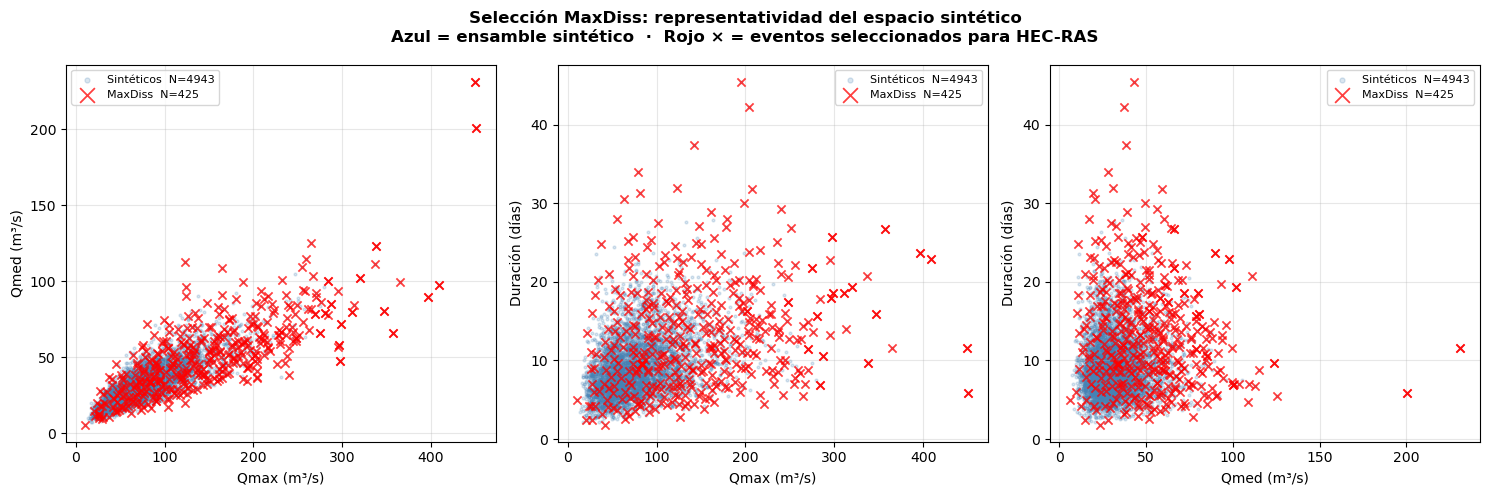

In [12]:
# --- Plot 3c: MaxDiss selection — 3-panel scatter ---
# Blue dots = full synthetic ensemble
# Red × = N_MAXDISS events selected by MaxDiss algorithm
_md_src = None
if EVENTOS_MAXDISS.exists():
    _md_src = pd.read_csv(EVENTOS_MAXDISS, index_col=0)
elif 'eventos_maxdiss' in dir() and not eventos_maxdiss.empty:
    _md_src = eventos_maxdiss

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
_pairs = [
    ('Qmax',    'Qmed',    'Qmax (m³/s)',    'Qmed (m³/s)'),
    ('Qmax',    'Duracion','Qmax (m³/s)',    'Duración (días)'),
    ('Qmed',    'Duracion','Qmed (m³/s)',    'Duración (días)'),
]
for ax, (cx, cy, lx, ly) in zip(axes, _pairs):
    if cx in synthetic.columns and cy in synthetic.columns:
        ax.scatter(synthetic[cx], synthetic[cy],
                   s=4, alpha=0.2, color='steelblue',
                   label=f'Sintéticos  N={len(synthetic)}')
    if _md_src is not None and cx in _md_src.columns and cy in _md_src.columns:
        ax.scatter(_md_src[cx], _md_src[cy],
                   s=35, alpha=0.75, color='red', marker='x', lw=1.3, zorder=5,
                   label=f'MaxDiss  N={len(_md_src)}')
    ax.set(xlabel=lx, ylabel=ly)
    ax.legend(fontsize=8, markerscale=1.8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Selección MaxDiss: representatividad del espacio sintético\n'
             'Azul = ensamble sintético  ·  Rojo × = eventos seleccionados para HEC-RAS',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROC_OUT_DIR / 'scatter_maxdiss_selection.png', dpi=150, bbox_inches='tight')
plt.show()
if _md_src is None:
    print('⚠  eventos_maxdiss.csv no disponible — ejecutar HydrographReconstructor primero')

---
## 6. MaxDiss hydrograph visualisation

Each MaxDiss centroid is associated with one observed hydrograph from the database 
(the nearest observed event in normalised space). The quadratic transform 
`Q_synt = a·Q² + b·Q` scales the observed hydrograph to match the centroid's 
target (Qmax, Qmed) exactly while preserving the shape.

**What to look for in the plots:**
- Hydrograph family coverage: each cluster type should have centroids spanning 
  the full Qmax range (low, medium, high peaks)
- No isolated centroids with unrealistic shapes (e.g., duration = 1 day but 
  Qmax = 500 m³/s — physically impossible for a 700 km² basin)


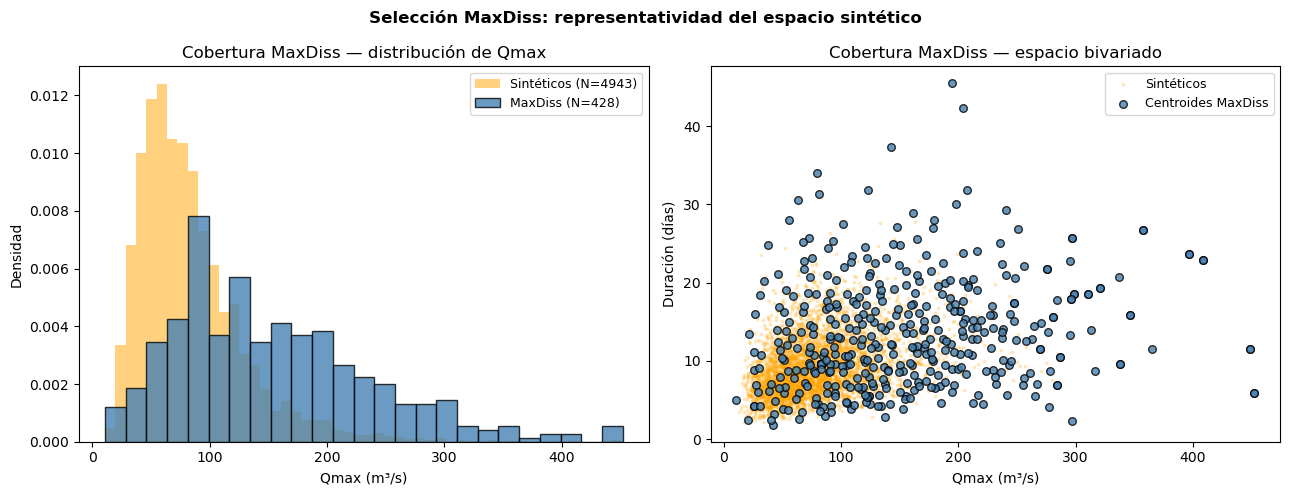

In [13]:
# Qmax distribution: MaxDiss centroids vs full synthetic ensemble
if not centroids_df.empty and 'Qmax' in centroids_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Histograma comparativo
    ax = axes[0]
    if 'Qmax' in synthetic.columns:
        ax.hist(synthetic['Qmax'], bins=50, density=True, alpha=0.5,
                color='orange', label=f'Sintéticos (N={len(synthetic)})', edgecolor='none')
    ax.hist(centroids_df['Qmax'], bins=25, density=True, alpha=0.8,
            color='steelblue', label=f'MaxDiss (N={len(centroids_df)})', edgecolor='k')
    ax.set(xlabel='Qmax (m³/s)', ylabel='Densidad',
           title='Cobertura MaxDiss — distribución de Qmax')
    ax.legend(fontsize=9)

    # Scatter: Qmax vs Duration
    ax = axes[1]
    if 'Qmax' in synthetic.columns and 'Duracion' in synthetic.columns:
        ax.scatter(synthetic['Qmax'], synthetic['Duracion'],
                   s=3, alpha=0.2, color='orange', label='Sintéticos')
    ax.scatter(centroids_df['Qmax'], centroids_df['Dur_h'] / 24.0,
               s=30, alpha=0.8, color='steelblue', edgecolors='k', zorder=5,
               label='Centroides MaxDiss')
    ax.set(xlabel='Qmax (m³/s)', ylabel='Duración (días)',
           title='Cobertura MaxDiss — espacio bivariado')
    ax.legend(fontsize=9)

    plt.suptitle('Selección MaxDiss: representatividad del espacio sintético',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROC_OUT_DIR / 'maxdiss_coverage.png', dpi=150)
    plt.show()

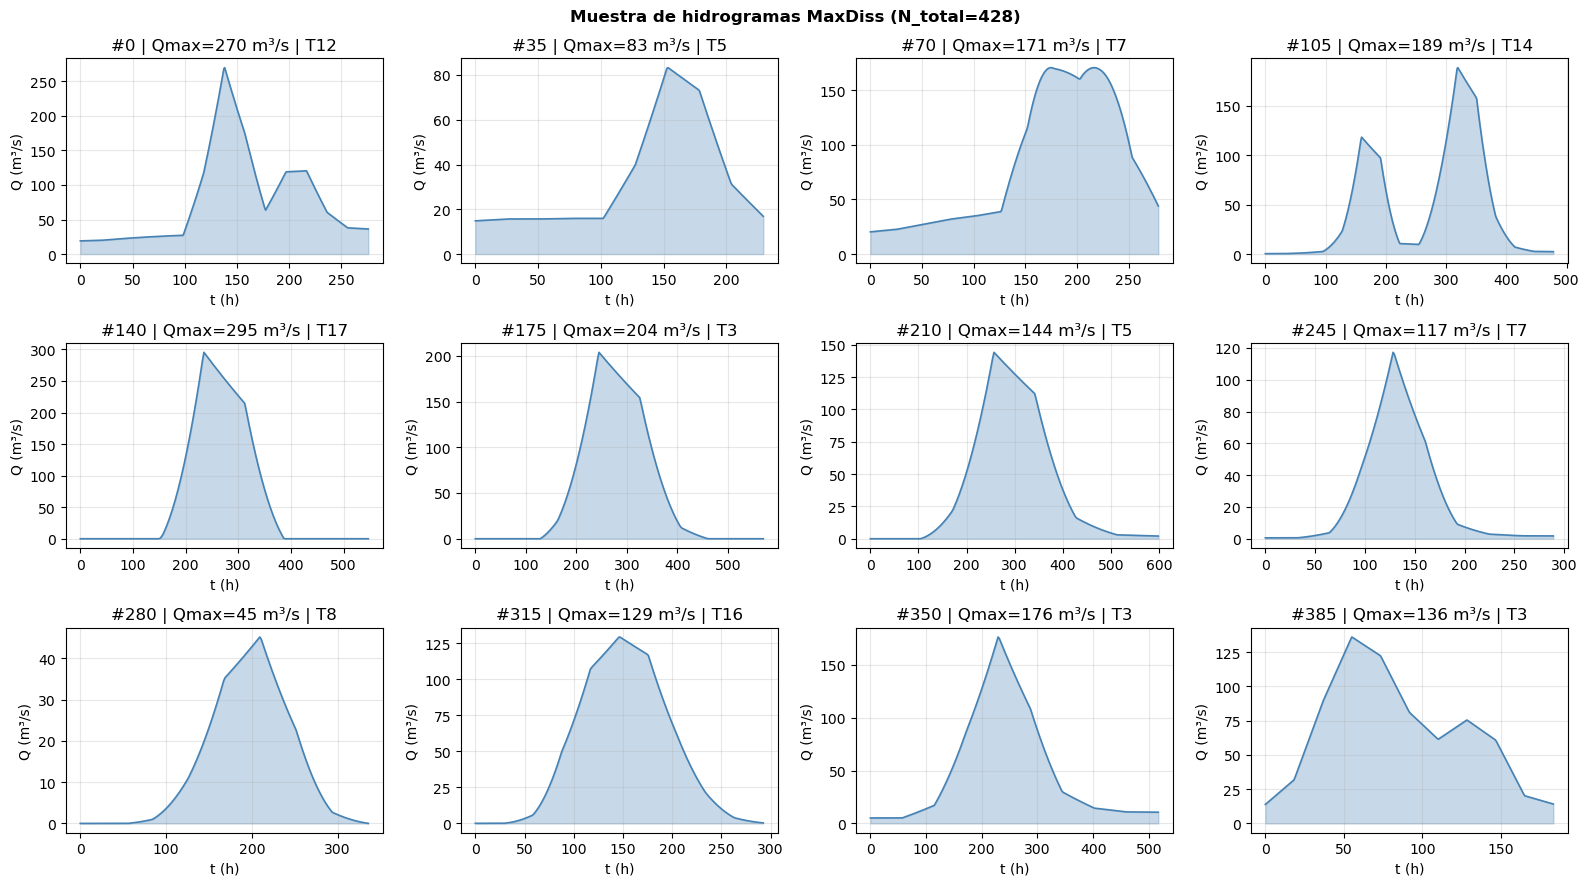

In [14]:
# Muestra de hidrogramas MaxDiss: 12 ejemplos representativos
if HYDRO_MAXDISS.exists():
    sample_files = hydro_files[::max(1, len(hydro_files) // 12)][:12]

    # Get hydrograph type if available
    tipo_map = {}
    if 'Tipo_Hidro' in synthetic.columns and 'Qmax' in synthetic.columns:
        for idx_row, row in synthetic.iterrows():
            tipo_map[idx_row] = row['Tipo_Hidro']

    colors_t = {0: 'steelblue', 1: 'darkorange', 2: 'forestgreen'}

    fig, axes = plt.subplots(3, 4, figsize=(16, 9))
    axes = axes.ravel()

    for ax, hf in zip(axes, sample_files):
        try:
            j = int(hf.stem.split('_')[1])
            df = pd.read_csv(hf, index_col=0)
            t  = df.index.astype(float) / 3600.0  # segundos → horas
            Q  = df.iloc[:, 0].values.astype(float)
            tipo = tipo_map.get(j, 0)
            c    = colors_t.get(int(tipo) if pd.notna(tipo) else 0, 'steelblue')
            ax.fill_between(t, Q, alpha=0.3, color=c)
            ax.plot(t, Q, lw=1.2, color=c)
            ax.set(title=f'#{j} | Qmax={Q.max():.0f} m³/s | T{int(tipo)}',
                   xlabel='t (h)', ylabel='Q (m³/s)')
            ax.grid(True, alpha=0.3)
        except Exception as e:
            ax.set_title(f'Error: {e}')

    plt.suptitle(f'Muestra de hidrogramas MaxDiss (N_total={len(hydro_files)})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROC_OUT_DIR / 'maxdiss_sample_hydros.png', dpi=150)
    plt.show()

## 6b. Flood map reconstruction method comparison

The hybrid methodology reconstructs flood inundation maps for synthetic events by
interpolating between HEC-RAS simulated centroids. This is methodologically valid
only when the centroid maps span the event space. In the release dataset, some
rasters may be reduced reference maps rather than a full 425-member hydraulic
simulation library, so the section is treated as an API/workflow check unless the
full `Simul_j.tif` collection is present.

Two methods are implemented in `FloodMapInterpolator`:

| Method | Description | Parameters |
|--------|-------------|------------|
| **KNN** (K-nearest neighbours) | Inverse-distance weighted average of the **k** nearest centroids | k=6 |
| **RBF** (Radial Basis Functions) | Gaussian kernel weighted average over **all** centroids | σ=auto |

**KNN** is local; **RBF** is smoother and more global. Both require hydraulic
support points that cover the target event range.


Evento de diseño T=100: Qmax=306 m³/s  Qmed=168 m³/s  Dur=11.9 días

KNN (k=6): índices seleccionados: [143   4  68 140 170  13]
  pesos: [0.1617 0.1842 0.1842 0.1575 0.1562 0.1562]  (suma=1.0000)

RBF: top-5 centroides con mayor peso:
  centroide #68: Qmax=298  w=0.0124
  centroide #4: Qmax=298  w=0.0124
  centroide #143: Qmax=313  w=0.0123
  centroide #140: Qmax=295  w=0.0123
  centroide #13: Qmax=287  w=0.0123

--- FloodMapInterpolator API ---
method="knn" → FloodMapInterpolator(..., method="knn", k_neighbors=6)
method="rbf" → FloodMapInterpolator(..., method="rbf", rbf_sigma=None)


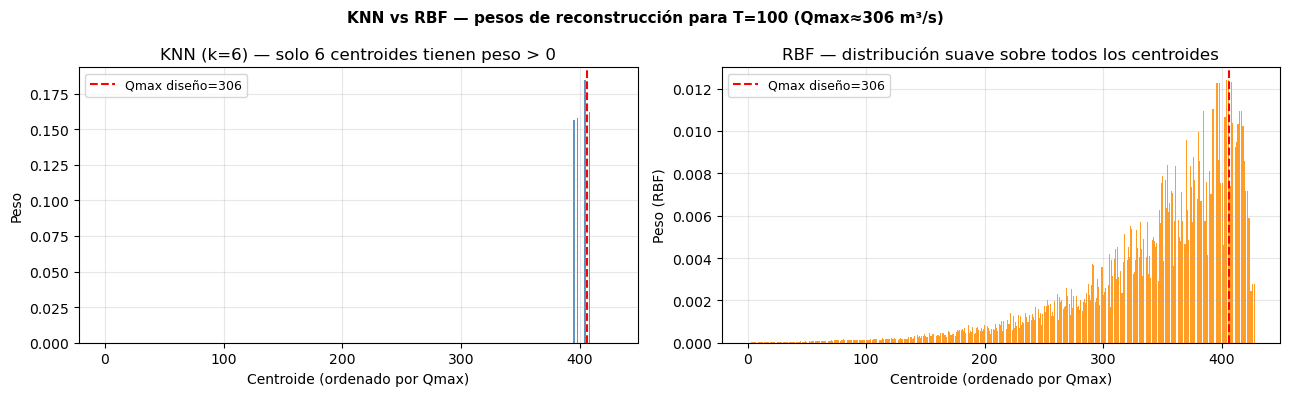

In [15]:
# hydro_metHab is populated in Section 7 below; use empty dict as default here
_hydro_mh = hydro_metHab if 'hydro_metHab' in dir() else {}

from pyhydra.climate.hybrid_downscaling.interpolation import _knn_weights, _rbf_weights
from pyhydra.climate.hybrid_downscaling import FloodMapInterpolator

# Compare KNN vs RBF weights for a test design event
if not centroids_df.empty and 'Qmax' in centroids_df.columns:

    # Construir feature matrix de centroides con columnas disponibles
    centroid_feat = pd.DataFrame({
        'Qmax':    centroids_df['Qmax'].values,
        'Qmed':    centroids_df.get('Qmed', centroids_df['Qmax'] * 0.55).values,
        'Duracion':centroids_df.get('Dur_h', centroids_df.get('Duracion', 48.0)).values / 24.0,
    }, index=centroids_df.index)

    # T=100 design event
    q_ref = _hydro_mh[100].max() if 100 in _hydro_mh else float(centroids_df['Qmax'].quantile(0.95))
    design_event = pd.DataFrame({
        'Qmax':    [q_ref],
        'Qmed':    [q_ref * 0.55],
        'Duracion':[centroid_feat['Duracion'].median()],
    })
    print(f'Evento de diseño T=100: Qmax={q_ref:.0f} m³/s  '
          f'Qmed={q_ref*0.55:.0f} m³/s  Dur={centroid_feat["Duracion"].median():.1f} días')

    k = min(6, len(centroid_feat) - 1)
    knn_pos, knn_w = _knn_weights(design_event, centroid_feat, k=k)  # (positions, weights)
    rbf_w          = _rbf_weights(design_event, centroid_feat)

    # Expandir pesos KNN a vector completo (cero para centroides no seleccionados)
    full_knn = np.zeros(len(centroid_feat))
    for idx, w in zip(knn_pos[0], knn_w[0]):
        full_knn[idx] = w

    print(f'\nKNN (k={k}): índices seleccionados: {knn_pos[0]}')
    print(f'  pesos: {knn_w[0].round(4)}  (suma={knn_w[0].sum():.4f})')
    print(f'\nRBF: top-5 centroides con mayor peso:')
    for idx in np.argsort(-rbf_w[0])[:5]:
        print(f'  centroide #{centroid_feat.index[idx]}: '
              f'Qmax={centroid_feat.iloc[idx]["Qmax"]:.0f}  w={rbf_w[0,idx]:.4f}')

    # Visualisation
    x_axis = np.arange(len(centroid_feat))
    sort_order = np.argsort(centroid_feat['Qmax'].values)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    ax.bar(range(len(centroid_feat)), full_knn[sort_order], color='steelblue', alpha=0.85)
    ax.axvline(np.searchsorted(centroid_feat['Qmax'].values[sort_order], q_ref),
               color='red', lw=1.5, ls='--', label=f'Qmax diseño={q_ref:.0f}')
    ax.set(xlabel='Centroide (ordenado por Qmax)', ylabel='Peso',
           title=f'KNN (k={k}) — solo {k} centroides tienen peso > 0')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.bar(range(len(centroid_feat)), rbf_w[0, sort_order], color='darkorange', alpha=0.85)
    ax.axvline(np.searchsorted(centroid_feat['Qmax'].values[sort_order], q_ref),
               color='red', lw=1.5, ls='--', label=f'Qmax diseño={q_ref:.0f}')
    ax.set(xlabel='Centroide (ordenado por Qmax)', ylabel='Peso (RBF)',
           title='RBF — distribución suave sobre todos los centroides')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.suptitle(f'KNN vs RBF — pesos de reconstrucción para T=100 (Qmax≈{q_ref:.0f} m³/s)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROC_OUT_DIR / 'reconstruction_weights_comparison.png', dpi=150)
    plt.show()

    # Example API call using RBF method
    SIM_DIR = PROC_DIR / 'flood_maps' / 'simulations'
    print(f'\n--- FloodMapInterpolator API ---')
    print(f'method="knn" → FloodMapInterpolator(..., method="knn", k_neighbors=6)')
    print(f'method="rbf" → FloodMapInterpolator(..., method="rbf", rbf_sigma=None)')
    if not SIM_DIR.exists():
        print(f'\n⚠  {SIM_DIR} no existe — la reconstrucción requiere Simul_j.tif de HEC-RAS')

else:
    print('centroids_df vacío — saltando comparación de métodos de reconstrucción.')

---
## 7. T-year hydrographs for HEC-RAS (Met-Hab)

The **Met-Hab** approach (Método Habitual) generates design hydrographs for 
standard return periods by associating each T-year Qmax (from the GEV fit in 
Notebook 03) with its "most likely" companion event in the synthetic ensemble:

1. For each T, compute Q_T from the GEV return level
2. Find the N_near nearest synthetic events in the Qmax-Qmed-Duration space with 
   Qmax ≈ Q_T (within a tolerance band)
3. Select the centroid of those N_near events as the T-year hydrograph characteristics
4. Scale the corresponding observed hydrograph to match

**Why use Met-Hab alongside the full 5000-event library?**  
Met-Hab produces the 5 standard design hydrographs (T=10, 25, 50, 100, 500) in the 
traditional regulatory format — required for flood hazard mapping under the 
Spanish SNCZI (Sistema Nacional de Cartografía de Zonas Inundables).


Hidrogramas Met-Hab disponibles: [2, 5, 10, 25, 50, 100, 200, 500]

Caudales pico Met-Hab:
 T_years  Qmax_m3s  Dur_h
       2 129.55038  456.0
       5 168.46187  456.0
      10 185.63127  456.0
      25 200.31323  456.0
      50 208.48242  456.0
     100 214.17767  456.0
     200 218.49515  456.0
     500 223.09412  456.0


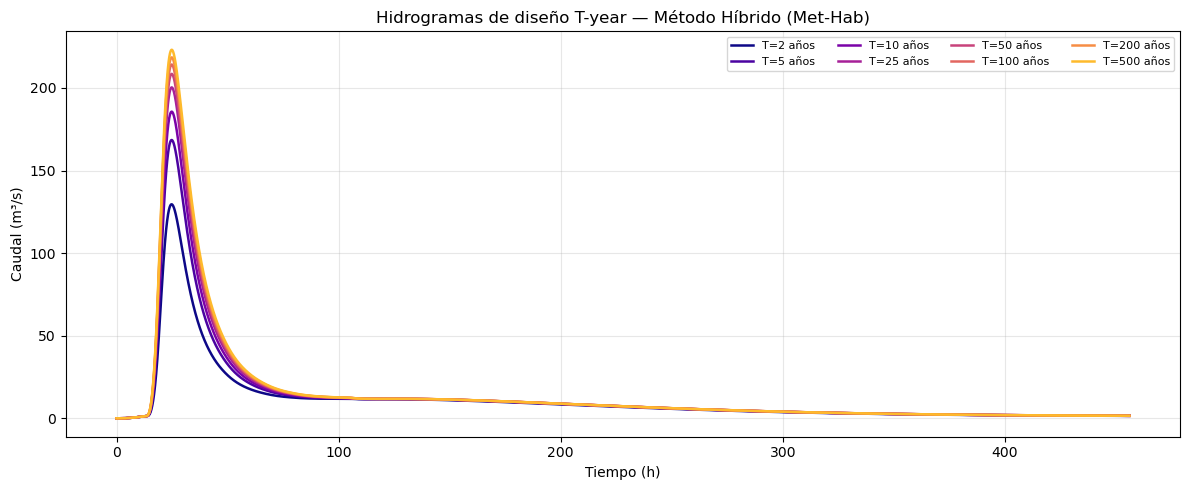

In [16]:
from scipy.stats import genextreme

MET_HAB_DIR = _session_or_shared('processed/hydrographs_maxdiss/Met_Hab')
hydro_metHab = {}

# ── Try loading pre-computed Met-Hab hydrograms ─────────────────────────────
if MET_HAB_DIR.exists():
    for T in RETURN_PERIODS:
        hf = MET_HAB_DIR / f'Hidrograma_T{T}.csv'
        if hf.exists():
            df = pd.read_csv(hf, index_col=0)
            s  = df.iloc[:, 0].astype(float)
            t_h = s.index.astype(float) / 3600.0  # s → h
            hydro_metHab[T] = pd.Series(s.values, index=t_h, name=f'T{T}')

# ── Generate if not found ───────────────────────────────────────────────────
if not hydro_metHab and not centroids_df.empty and 'Qmax' in centroids_df.columns:
    print('Generando hidrogramas Met-Hab (GEV + centroide más cercano)...')
    MET_HAB_DIR.mkdir(parents=True, exist_ok=True)

    # Fit GEV to observed event Qmax (peaks-over-threshold sample)
    qmax_obs = eventos_obs['Qmax'].dropna().values
    c_gev, loc_gev, scale_gev = genextreme.fit(qmax_obs)
    print(f'  GEV ajustada: ξ={c_gev:.3f}  μ={loc_gev:.1f}  σ={scale_gev:.1f}')

    q_min_c = centroids_df['Qmax'].min()
    q_max_c = centroids_df['Qmax'].max()

    for T in RETURN_PERIODS:
        Q_T = float(genextreme.ppf(1.0 - 1.0 / T, c_gev, loc_gev, scale_gev))
        Q_T = float(np.clip(Q_T, q_min_c, q_max_c))

        # Nearest MaxDiss centroid in Qmax space
        j_near = int((centroids_df['Qmax'] - Q_T).abs().idxmin())
        Q_near = float(centroids_df.loc[j_near, 'Qmax'])

        hf = HYDRO_MAXDISS / f'Hidrograma_{j_near}.csv'
        if not hf.exists():
            print(f'  T={T}: hidrograma #{j_near} no encontrado, saltando.')
            continue

        df  = pd.read_csv(hf, index_col=0)
        Q   = df.iloc[:, 0].values.astype(float)
        t   = df.index.astype(float)

        # Linear scaling to match Q_T exactly
        scale_f = Q_T / Q_near if Q_near > 0 else 1.0
        Q_scaled = Q * scale_f

        out = pd.DataFrame({'Q_m3/s': Q_scaled}, index=t)
        out.to_csv(MET_HAB_DIR / f'Hidrograma_T{T}.csv')

        t_h = t / 3600.0
        hydro_metHab[T] = pd.Series(Q_scaled, index=t_h, name=f'T{T}')
        print(f'  T={T:3d} años: Q_T={Q_T:.0f} m³/s  →  centroide #{j_near} '
              f'(Qmax={Q_near:.0f}) × {scale_f:.3f}')

print(f'Hidrogramas Met-Hab disponibles: {list(hydro_metHab.keys())}')

if hydro_metHab:
    colors_T = plt.cm.plasma(np.linspace(0, 0.85, len(hydro_metHab)))
    fig, ax = plt.subplots(figsize=(12, 5))
    for (T, h), c in zip(hydro_metHab.items(), colors_T):
        ax.plot(h.index, h.values, lw=1.8, color=c, label=f'T={T} años')
    ax.set(xlabel='Tiempo (h)', ylabel='Caudal (m³/s)',
           title='Hidrogramas de diseño T-year — Método Híbrido (Met-Hab)')
    ax.legend(ncol=4, fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PROC_OUT_DIR / 'hidrogramas_metHab_Tyear.png', dpi=150)
    plt.show()

    # Peak flow table
    peak_table = pd.DataFrame({
        'T_years': list(hydro_metHab.keys()),
        'Qmax_m3s': [h.max() for h in hydro_metHab.values()],
        'Dur_h':    [h.index[-1] - h.index[0] for h in hydro_metHab.values()],
    })
    print('\nCaudales pico Met-Hab:')
    print(peak_table.to_string(index=False))
else:
    print('⚠  No se pudieron generar hidrogramas Met-Hab.')
    print('   Compruebe que centroids_df y los hidrogramas MaxDiss están disponibles.')

## 8. Summary and preparation for HEC-RAS

Outputs from this notebook used in **Notebook 07 (HEC-RAS)**:

| File | Use in NB07 |
|---|---|
| `hydrographs_maxdiss/Hidrograma_*.csv` | 425 hydrographs for HEC-RAS simulation |
| `hydrographs_maxdiss/Met_Hab/Hidrograma_T*.csv` | T-year hydrographs for validation |
| `matriz_sintetica_maxdiss.csv` | Event metadata (Qmax, type, …) |
| `eventos_maxdiss.csv` | MaxDiss-selected events |


In [17]:
print('=' * 55)
print('RESUMEN — Notebook 06')
print('=' * 55)

n_obs_events = len(eventos_obs) if 'eventos_obs' in dir() else '—'
n_synth      = len(synthetic)   if 'synthetic' in dir()   else '—'
n_maxdiss_h  = len(hydro_files) if 'hydro_files' in dir() else '—'
n_metHab     = len(hydro_metHab)

print(f'  Eventos observados          : {n_obs_events}')
print(f'  Eventos sintéticos (cópula) : {n_synth}')
print(f'  Hidrogramas MaxDiss         : {n_maxdiss_h}')
print(f'  Hidrogramas T-year Met-Hab  : {n_metHab}')

met_hab_available = MET_HAB_DIR.exists() and n_metHab > 0
maxdiss_available = len(hydro_files) >= N_MAXDISS if 'hydro_files' in dir() else False

print()
print(f'  [{ "OK" if maxdiss_available else "!!" }] Hidrogramas MaxDiss listos para HEC-RAS')
print(f'  [{ "OK" if met_hab_available else "!!" }] Hidrogramas Met-Hab listos para HEC-RAS')
print()
print('→ Continuar en Notebook 07: 07_hec_ras_hydraulics.ipynb')
print('=' * 55)

RESUMEN — Notebook 06
  Eventos observados          : 262
  Eventos sintéticos (cópula) : 4943
  Hidrogramas MaxDiss         : 428
  Hidrogramas T-year Met-Hab  : 8

  [OK] Hidrogramas MaxDiss listos para HEC-RAS
  [OK] Hidrogramas Met-Hab listos para HEC-RAS

→ Continuar en Notebook 07: 07_hec_ras_hydraulics.ipynb
